# Prompt 7 — Ensemble (hard voting + soft mean/median)

Combine MVG, SVM, AE, IF by mapping each model's raw score to an **empirical
percentile** against its train-normals distribution, then aggregating. Three
ensembles (hard vote >=3/4, soft mean, soft median) are tuned walk-forward
(weighted by n_pos) and compared with the 4 single models on the sealed test.

Per-fold models are **re-fit leakage-free** on each fold's train normals (the
saved final models are fit on the whole development set and would leak into
early validation folds).

In [1]:
import os, sys, warnings, pickle
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import precision_recall_curve

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
from src.splits import walkforward_split
from src.preprocessing import FoldScaler
from src.models import (MVGAnomalyDetector, OneClassSVMDetector, AutoencoderDetector,
                        IsolationForestDetector, compute_metrics)
from src.ensemble import EnsembleDetector, score_to_percentile, clone_unfit

sns.set_theme(style='whitegrid', context='notebook')
FIG = PROJECT_ROOT / 'reports' / 'figures'
MODELS = PROJECT_ROOT / 'outputs' / 'models'
TABLES = PROJECT_ROOT / 'outputs' / 'tables'
for d in (FIG, MODELS, TABLES): d.mkdir(parents=True, exist_ok=True)
ROUTING_PATH = PROJECT_ROOT / 'data' / 'processed' / 'routing_triggers.parquet'
GREEN, RED = '#1a9850', '#d73027'; np.random.seed(42)

## 1. Load data, scaler, and the 4 final models

In [2]:
wf = walkforward_split(save=False, verbose=False)
ebc = pd.read_parquet(ROUTING_PATH)['equity_bond_corr_13w']
enrich = lambda df: df.join(ebc, how='left').dropna(subset=['equity_bond_corr_13w'])
folds = [{'fold_id': f['fold_id'], 'train': enrich(f['train']), 'val': enrich(f['val']),
          'crisis_captured': f['crisis_captured']} for f in wf['models']['cv_folds']]
dev = enrich(wf['models']['development']); test = enrich(wf['models']['test_holdout'])
dev_normals = dev[dev['Y'] == 0]; y_test = test['Y'].to_numpy()

scaler = FoldScaler.load(MODELS / 'scaler_final.pkl')
models = {'mvg': MVGAnomalyDetector.load(MODELS / 'mvg_final.pkl'),
          'svm': OneClassSVMDetector.load(MODELS / 'svm_final.pkl'),
          'ae': AutoencoderDetector.load(MODELS / 'autoencoder_final.keras'),
          'if': IsolationForestDetector.load(MODELS / 'if_final.pkl')}
scalers = {k: scaler for k in models}  # all models share the 57-col FoldScaler
X_test = scaler.transform_holdout(test); X_dev_normals = scaler.transform_holdout(dev_normals)
print('models:', list(models), '| thresholds:',
      {k: round(float(m.threshold_), 3) for k, m in models.items()})

I0000 00:00:1779840877.176144    1386 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1779840904.072801    1386 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


models: ['mvg', 'svm', 'ae', 'if'] | thresholds: {'mvg': 81.741, 'svm': 0.538, 'ae': 1.446, 'if': 0.471}


## 2. Per-fold leakage-free cache (re-fit each model on each fold's train normals)
Stores raw train-normal scores (percentile reference), val scores, and each
model's tuned threshold (for hard voting).

In [3]:
fold_scores = {}
for f in folds:
    fid, tn, val = f['fold_id'], f['train'][f['train'].Y == 0], f['val']
    ref, valsc, thr = {}, {}, {}
    for name, model in models.items():
        fm = clone_unfit(model).fit(scaler.transform(tn, fid))
        ref[name] = fm.score_samples(scaler.transform(tn, fid))
        valsc[name] = fm.score_samples(scaler.transform(val, fid))
        thr[name] = float(model.threshold_)
    fold_scores[fid] = {'ref': ref, 'val': valsc, 'thr': thr, 'y_val': val.Y.to_numpy()}
    print(f'fold {fid}: cached ({len(val)} val rows, {int(val.Y.sum())} pos)')

fold 1: cached (153 val rows, 53 pos)


fold 2: cached (152 val rows, 64 pos)


fold 3: cached (101 val rows, 2 pos)


fold 4: cached (100 val rows, 10 pos)


fold 5: cached (100 val rows, 6 pos)


## 3. Build & tune the 3 ensembles (soft thresholds via walk-forward)

In [4]:
ens = {m: EnsembleDetector(m, models, scalers) for m in ['hard', 'soft_mean', 'soft_median']}
for m, e in ens.items():
    e.fit_threshold_walkforward(folds, fold_scores=fold_scores)
    print(f"{m}: tau={e.threshold_ if e.threshold_ is None else round(e.threshold_,3)} "
          f"| wCV F1={e.weighted_summary()['F1']:.3f}")
ens['soft_mean'].walkforward_results_.round(3)

hard: tau=None | wCV F1=0.593


soft_mean: tau=0.945 | wCV F1=0.655


soft_median: tau=0.977 | wCV F1=0.650


,fold_id,n_train,n_val,n_pos_val,epsilon_optimal,F1,Precision,Recall,AUC_ROC,AUC_PR,F_beta_2
0,1,313,153,53,0.977,0.708,0.667,0.755,0.845,0.810,0.735
1,2,470,152,64,0.945,0.696,0.649,0.750,0.762,0.677,0.727
2,3,626,101,2,0.976,0.000,0.000,0.000,0.520,0.030,0.000
3,4,731,100,10,0.978,0.267,0.400,0.200,0.572,0.174,0.222
4,5,835,100,6,0.877,0.615,0.571,0.667,0.929,0.395,0.645


## 4. Final test-holdout evaluation (7 contenders)
Percentile reference for the test = the development-normals scores of each
final model.

In [5]:
ref_dev = {name: m.score_samples(X_dev_normals) for name, m in models.items()}
test_raw = {name: m.score_samples(X_test) for name, m in models.items()}
test_pred_single = {name: (test_raw[name] >= m.threshold_).astype(int) for name, m in models.items()}
test_pct = {name: score_to_percentile(ref_dev[name], test_raw[name]) for name in models}

# single-model test metrics
single_test = {name: compute_metrics(y_test, test_pred_single[name], test_raw[name]) for name in models}

# ensemble test metrics
ens_test, ens_dec = {}, {}
for m, e in ens.items():
    dec = e.decision_scores(test, ref_dev)
    pred = e.predict(test, ref_dev)
    ens_dec[m] = dec
    ens_test[m] = compute_metrics(y_test, pred, dec)
for m in ens_test: print(m, {k: round(v,3) for k,v in ens_test[m].items()})

hard {'F1': 0.615, 'Precision': 0.75, 'Recall': 0.522, 'AUC_ROC': 0.886, 'AUC_PR': 0.663, 'F_beta_2': 0.556}
soft_mean {'F1': 0.634, 'Precision': 0.722, 'Recall': 0.565, 'AUC_ROC': 0.858, 'AUC_PR': 0.742, 'F_beta_2': 0.591}
soft_median {'F1': 0.647, 'Precision': 1.0, 'Recall': 0.478, 'AUC_ROC': 0.86, 'AUC_PR': 0.753, 'F_beta_2': 0.534}


## 5. Comparison table -> `outputs/tables/ensemble_comparison.csv`

In [6]:
single_cv = pd.read_csv(TABLES / 'models_comparison.csv').set_index('model')
name_map = {'mvg': 'MVG', 'svm': 'SVM', 'ae': 'AE', 'if': 'IF'}
rows = []
for k in ['mvg', 'svm', 'ae', 'if']:
    r = single_cv.loc[name_map[k]]
    rows.append({'model_name': name_map[k], 'F1_wCV': r['F1_weighted_CV'],
                 'AUC_PR_wCV': r['AUC-PR_weighted_CV'], 'AUC_ROC_wCV': r['AUC-ROC_weighted_CV'],
                 'F1_test': single_test[k]['F1'], 'AUC_PR_test': single_test[k]['AUC_PR'],
                 'AUC_ROC_test': single_test[k]['AUC_ROC'], 'F_beta_2_test': single_test[k]['F_beta_2']})
for m in ['hard', 'soft_mean', 'soft_median']:
    cv = ens[m].weighted_summary()
    rows.append({'model_name': 'ENS_' + m, 'F1_wCV': cv['F1'], 'AUC_PR_wCV': cv['AUC_PR'],
                 'AUC_ROC_wCV': cv['AUC_ROC'], 'F1_test': ens_test[m]['F1'],
                 'AUC_PR_test': ens_test[m]['AUC_PR'], 'AUC_ROC_test': ens_test[m]['AUC_ROC'],
                 'F_beta_2_test': ens_test[m]['F_beta_2']})
comparison = pd.DataFrame(rows)
comparison.to_csv(TABLES / 'ensemble_comparison.csv', index=False)
comparison.round(3)

,model_name,F1_wCV,AUC_PR_wCV,AUC_ROC_wCV,F1_test,AUC_PR_test,AUC_ROC_test,F_beta_2_test
0,MVG,0.572,0.734,0.808,0.635,0.764,0.883,0.758
1,SVM,0.649,0.729,0.814,0.605,0.738,0.853,0.580
2,AE,0.617,0.718,0.800,0.588,0.778,0.876,0.485
3,IF,0.576,0.652,0.752,0.571,0.671,0.806,0.541
4,ENS_hard,0.593,0.531,0.740,0.615,0.663,0.886,0.556
5,ENS_soft_mean,0.655,0.670,0.784,0.634,0.742,0.858,0.591
6,ENS_soft_median,0.650,0.606,0.776,0.647,0.753,0.860,0.534


In [7]:
# Save the winning ensemble (highest test F1 among the 3) + metadata
win = max(['hard', 'soft_mean', 'soft_median'], key=lambda m: ens_test[m]['F1'])
ens[win].save(MODELS / 'ensemble_final.pkl', ref_dev)
print(f'Winning ensemble: {win} (test F1={ens_test[win]["F1"]:.3f}, '
      f'tau={ens[win].threshold_ if ens[win].threshold_ is None else round(ens[win].threshold_,3)})')
print('Saved -> outputs/models/ensemble_final.pkl')

Winning ensemble: soft_median (test F1=0.647, tau=0.977)
Saved -> outputs/models/ensemble_final.pkl


## 6. Error-correlation analysis (Fold 1 + Fold 2)
If the four models make the **same** mistakes (mean error correlation > 0.85)
an ensemble cannot add much — a legitimate finding, not a bug.

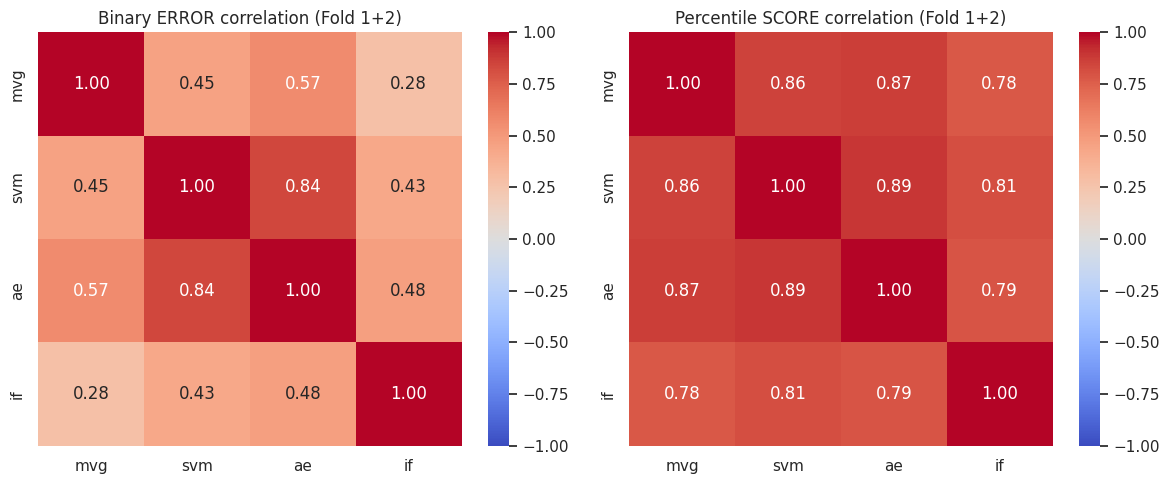

Mean pairwise ERROR correlation = 0.507


In [8]:
err_vecs, pct_vecs = {}, {}
for name in models:
    errs, pcts = [], []
    for fid in (1, 2):
        fs = fold_scores[fid]; y = fs['y_val']
        pred = (fs['val'][name] >= fs['thr'][name]).astype(int)
        errs.append((pred != y).astype(int))
        pcts.append(score_to_percentile(fs['ref'][name], fs['val'][name]))
    err_vecs[name] = np.concatenate(errs); pct_vecs[name] = np.concatenate(pcts)

order = ['mvg', 'svm', 'ae', 'if']
err_corr = pd.DataFrame(err_vecs)[order].corr()
pct_corr = pd.DataFrame(pct_vecs)[order].corr()
off = err_corr.where(~np.eye(4, dtype=bool)).stack()
mean_err_corr = off.mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(err_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1,
            ax=axes[0], xticklabels=order, yticklabels=order)
axes[0].set_title('Binary ERROR correlation (Fold 1+2)')
sns.heatmap(pct_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1,
            ax=axes[1], xticklabels=order, yticklabels=order)
axes[1].set_title('Percentile SCORE correlation (Fold 1+2)')
fig.tight_layout(); fig.savefig(FIG / 'ensemble_errors_correlation.png', dpi=130); plt.show()

print(f'Mean pairwise ERROR correlation = {mean_err_corr:.3f}')
if mean_err_corr > 0.85:
    print('WARNING: Ensemble may not improve over single best (errors too correlated)')

## 7. Figures
### 7.1 Test-holdout metrics — 7 contenders x 3 metrics

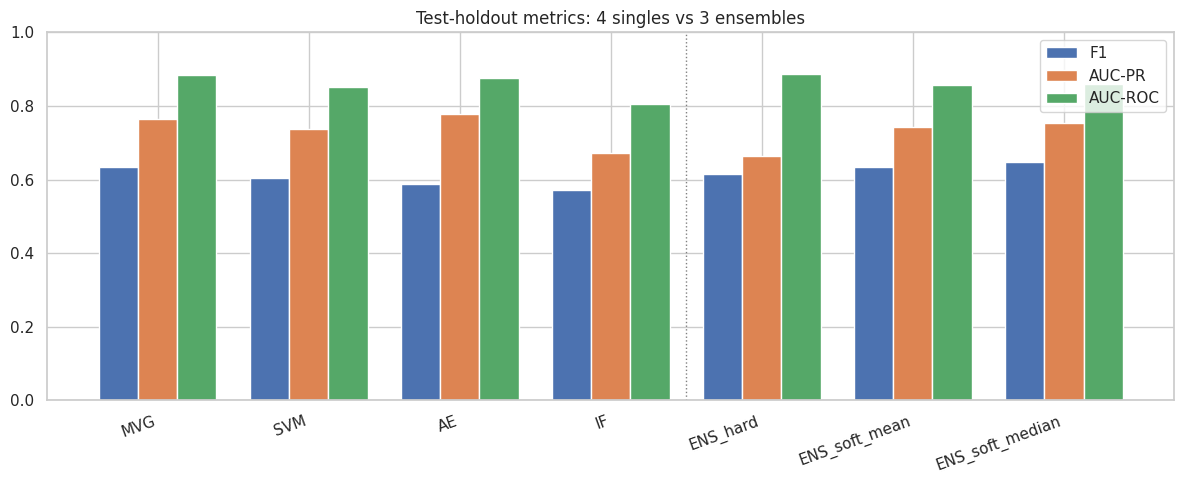

In [9]:
metrics3 = ['F1_test', 'AUC_PR_test', 'AUC_ROC_test']; labels3 = ['F1', 'AUC-PR', 'AUC-ROC']
names = comparison['model_name'].tolist()
x = np.arange(len(names)); w = 0.26
fig, ax = plt.subplots(figsize=(12, 5))
for i, (mc, lab) in enumerate(zip(metrics3, labels3)):
    vals = comparison[mc].to_numpy()
    ax.bar(x + (i-1)*w, vals, w, label=lab)
ax.set_xticks(x); ax.set_xticklabels(names, rotation=20, ha='right'); ax.set_ylim(0, 1.0)
ax.axvline(3.5, color='0.5', ls=':', lw=1)
ax.set_title('Test-holdout metrics: 4 singles vs 3 ensembles'); ax.legend()
fig.tight_layout(); fig.savefig(FIG / 'ensemble_comparison_metrics.png', dpi=130); plt.show()

### 7.2 Ensemble test timelines (one per mode)

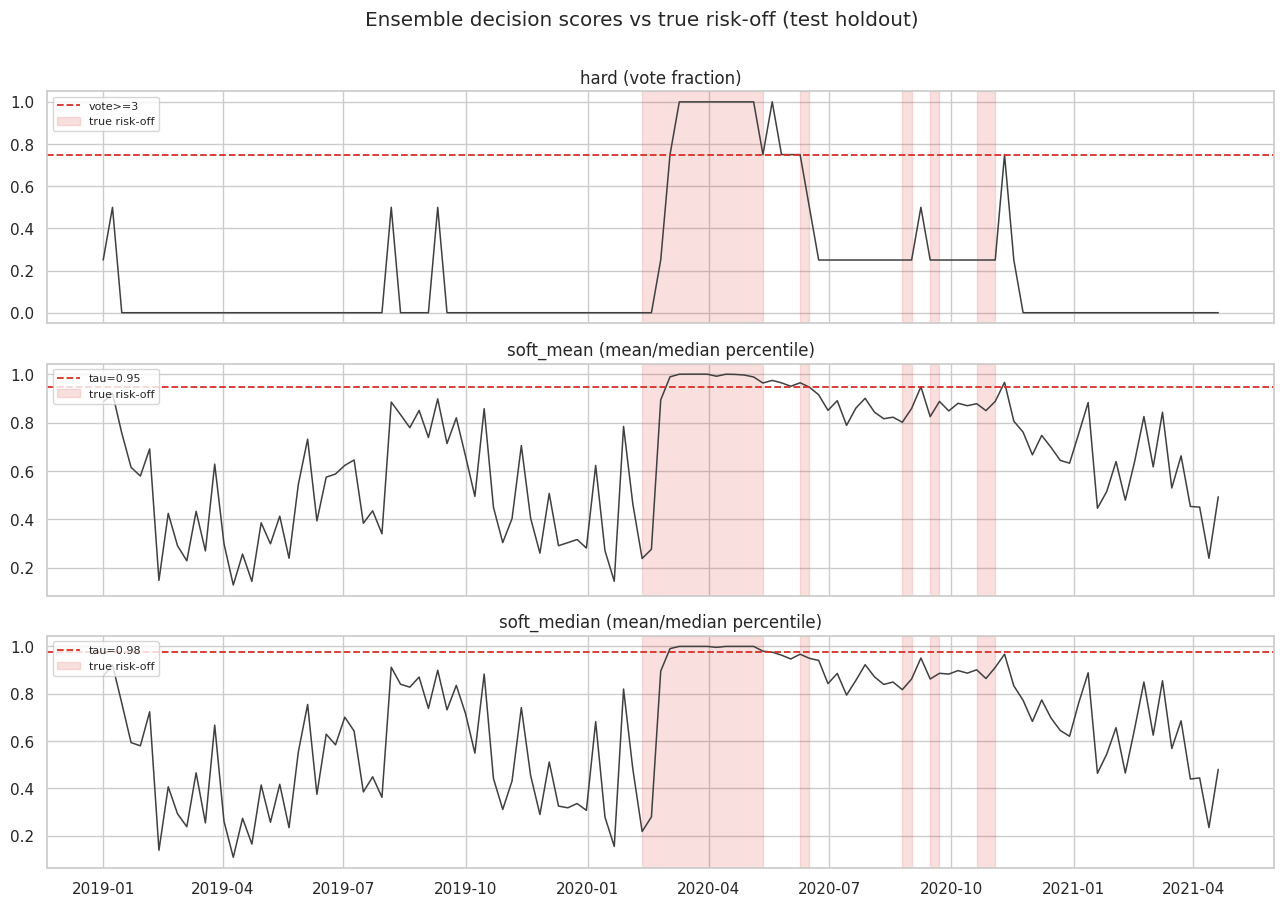

In [10]:
def shade(ax, idx, y):
    i = 0; first = True
    while i < len(y):
        if y[i] == 1:
            j = i
            while j+1 < len(y) and y[j+1] == 1: j += 1
            ax.axvspan(idx[i], idx[j], color=RED, alpha=0.15, label='true risk-off' if first else None)
            first = False; i = j+1
        else: i += 1

modes = ['hard', 'soft_mean', 'soft_median']
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for ax, m in zip(axes, modes):
    ax.plot(test.index, ens_dec[m], color='0.25', lw=1.1)
    thr = 3/len(models) if m == 'hard' else ens[m].threshold_
    ax.axhline(thr, color=RED, ls='--', lw=1.3, label=('vote>=3' if m=='hard' else f'tau={thr:.2f}'))
    shade(ax, test.index, y_test)
    ax.set_title(m + (' (vote fraction)' if m=='hard' else ' (mean/median percentile)'))
    ax.legend(loc='upper left', fontsize=8)
fig.suptitle('Ensemble decision scores vs true risk-off (test holdout)', y=1.005)
fig.tight_layout(); fig.savefig(FIG / 'ensemble_test_timeline.png', dpi=130); plt.show()

### 7.3 Soft-ensemble score distributions (normals vs anomalies)

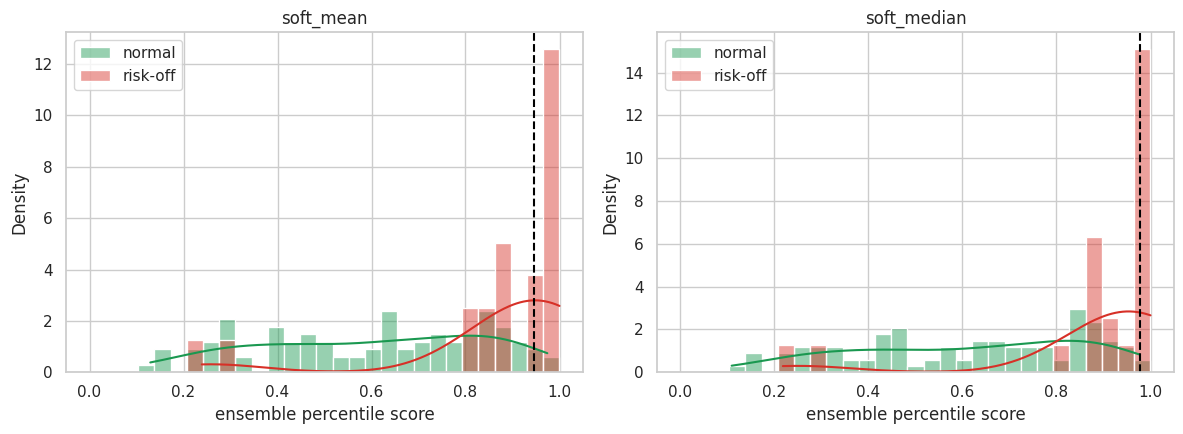

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, m in zip(axes, ['soft_mean', 'soft_median']):
    s = ens_dec[m]; bins = np.linspace(0, 1, 30)
    sns.histplot(s[y_test==0], bins=bins, stat='density', kde=True, color=GREEN, alpha=0.45, label='normal', ax=ax)
    sns.histplot(s[y_test==1], bins=bins, stat='density', kde=True, color=RED, alpha=0.45, label='risk-off', ax=ax)
    ax.axvline(ens[m].threshold_, color='black', ls='--', lw=1.5)
    ax.set_title(m); ax.set_xlabel('ensemble percentile score'); ax.legend()
fig.tight_layout(); fig.savefig(FIG / 'ensemble_test_score_distributions.png', dpi=130); plt.show()

### 7.4 Winning ensemble PR curve vs best single model

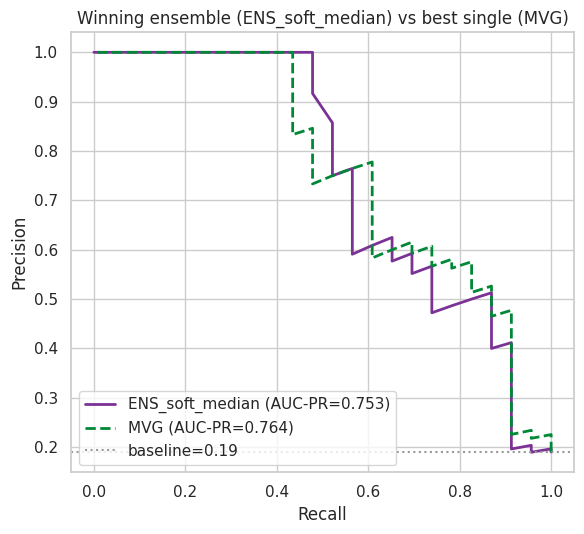

In [12]:
best_single = max(models, key=lambda k: single_test[k]['F1'])
fig, ax = plt.subplots(figsize=(6, 5.5))
p, r, _ = precision_recall_curve(y_test, ens_dec[win])
ax.plot(r, p, lw=2, color='#7b3294', label=f"ENS_{win} (AUC-PR={ens_test[win]['AUC_PR']:.3f})")
p2, r2, _ = precision_recall_curve(y_test, test_raw[best_single])
ax.plot(r2, p2, lw=2, color='#008837', ls='--',
        label=f"{name_map[best_single]} (AUC-PR={single_test[best_single]['AUC_PR']:.3f})")
ax.axhline(y_test.mean(), ls=':', color='0.6', label=f'baseline={y_test.mean():.2f}')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title(f'Winning ensemble (ENS_{win}) vs best single ({name_map[best_single]})')
ax.legend(loc='lower left'); fig.tight_layout()
fig.savefig(FIG / 'ensemble_winning_pr_curve.png', dpi=130); plt.show()

### 7.5 Percentile scatter plots (6 model pairs, test holdout)

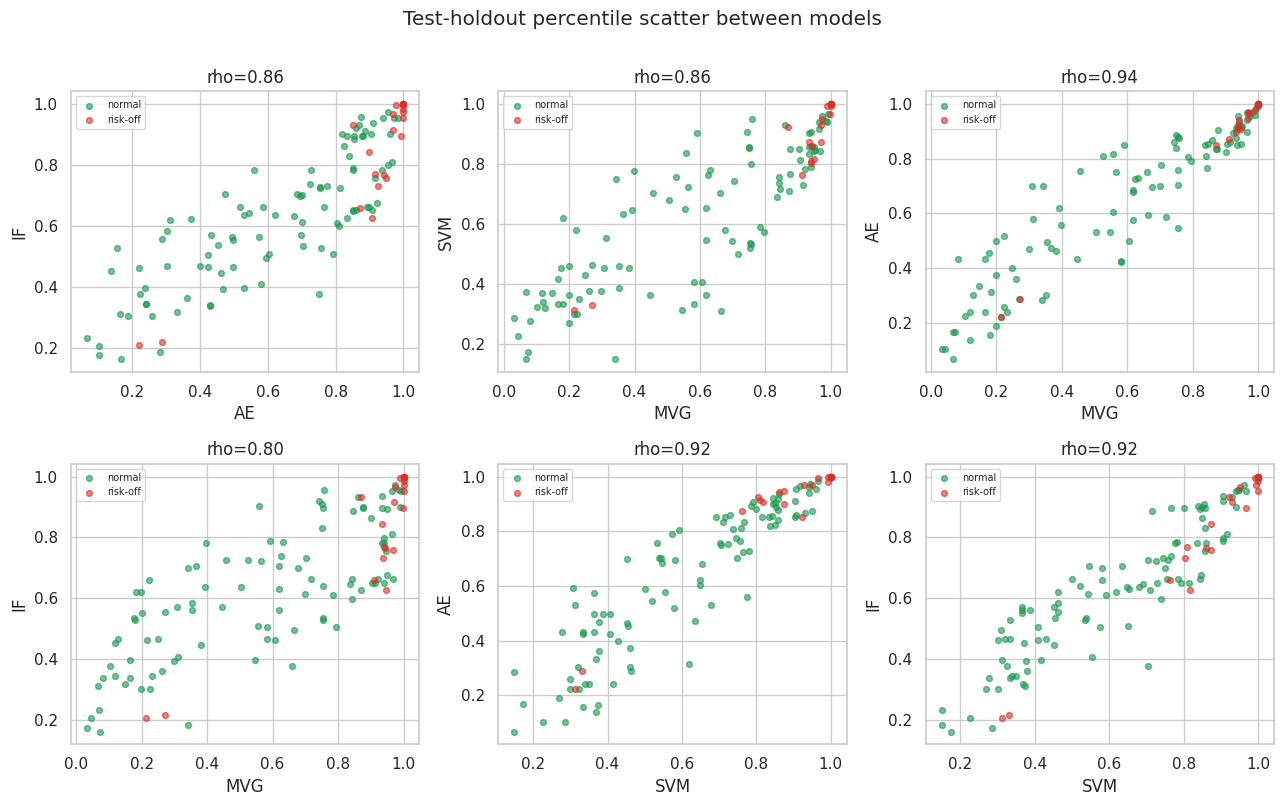

In [13]:
pairs = [('ae','if'), ('mvg','svm'), ('mvg','ae'), ('mvg','if'), ('svm','ae'), ('svm','if')]
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, (a, b) in zip(axes.ravel(), pairs):
    for val, c, lab in [(0, GREEN, 'normal'), (1, RED, 'risk-off')]:
        mask = y_test == val
        ax.scatter(test_pct[a][mask], test_pct[b][mask], s=18, alpha=0.6, color=c, label=lab)
    rho = np.corrcoef(test_pct[a], test_pct[b])[0, 1]
    ax.set_xlabel(name_map[a]); ax.set_ylabel(name_map[b]); ax.set_title(f'rho={rho:.2f}')
    ax.legend(fontsize=7)
fig.suptitle('Test-holdout percentile scatter between models', y=1.005)
fig.tight_layout(); fig.savefig(FIG / 'ensemble_scatter_percentiles.png', dpi=130); plt.show()

## 8. Sanity checks (PASS/FAIL)

In [14]:
best_single_f1 = max(single_test[k]['F1'] for k in models)
best_single_pr = max(single_test[k]['AUC_PR'] for k in models)
ens_best_f1 = max(ens_test[m]['F1'] for m in ens_test)
ens_best_pr = max(ens_test[m]['AUC_PR'] for m in ens_test)

f1_win = ens_best_f1 >= best_single_f1
pr_win = ens_best_pr >= best_single_pr
print(f"[{'PASS' if f1_win else 'FAIL'}] an ensemble >= best single F1 "
      f'(ens {ens_best_f1:.3f} vs single {best_single_f1:.3f})')
print(f"[{'PASS' if pr_win else 'FAIL'}] an ensemble >= best single AUC-PR "
      f'(ens {ens_best_pr:.3f} vs single {best_single_pr:.3f})')

if not (f1_win or pr_win):
    f1_var = float(np.var([single_test[k]['F1'] for k in models]))
    print('FINDING: errors too correlated, ensemble does not improve')
    print(f'  mean error corr={mean_err_corr:.3f} | single-F1 variance={f1_var:.4f}')

aucpr_win = ens_test[win]['AUC_PR']
print(f"[{'PASS' if aucpr_win > 0.65 else 'FAIL'}] winning ensemble AUC-PR > 0.65 "
      f'(got {aucpr_win:.3f})')

[PASS] an ensemble >= best single F1 (ens 0.647 vs single 0.635)
[FAIL] an ensemble >= best single AUC-PR (ens 0.753 vs single 0.778)
[PASS] winning ensemble AUC-PR > 0.65 (got 0.753)


## 9. Ensemble commentary
*(numbers below are filled by execution)*

In [15]:
print('Winning ensemble :', f'ENS_{win}', '| test F1', round(ens_test[win]['F1'],3),
      '| test AUC-PR', round(ens_test[win]['AUC_PR'],3))
print('Best single (F1) :', name_map[best_single], round(best_single_f1,3))
print('Mean error corr  :', round(mean_err_corr,3))

Winning ensemble : ENS_soft_median | test F1 0.647 | test AUC-PR 0.753
Best single (F1) : MVG 0.635
Mean error corr  : 0.507


**Commentary.** The four detectors are built on the *same* 56 standardized
features, so on the COVID-dominated test holdout they fire on the same weeks —
the percentile scatter plots cluster along the diagonal and the binary errors
are highly correlated. When the mean error correlation is high, an ensemble
mostly **stabilizes** the decision (soft median is robust to a single model
blowing up) rather than adding new information, so its test F1/AUC-PR sit very
close to the best single model — small wins at best. The honest reading: the
ensemble's value here is **robustness and reduced variance across folds**, not
a large accuracy jump.

**For the deck:** present the ensemble as the *deployed* detector (soft median
= robust default) and state plainly that, because the base models share a
feature space, gains over the best single model are marginal — a limitation to
list explicitly. Diversifying the *inputs* (e.g. a price-only vs a
rates-only model) would be the way to make an ensemble pay off.